In [1]:
# Dependencies
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu124
!pip install kaggle huggingface-hub tqdm matplotlib scikit-learn Pillow

Looking in indexes: https://download.pytorch.org/whl/cu124


In [2]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name())

2.10.0+cu128
True
NVIDIA A100-SXM4-40GB


In [4]:
# Kaggle auth
import os
from google.colab import files

files.upload()

os.makedirs("/root/.kaggle", exist_ok=True)
os.rename("kaggle.json", "/root/.kaggle/kaggle.json")

Saving kaggle.json to kaggle (1).json


In [7]:
# Download and verify dataset
import kaggle

kaggle.api.dataset_download_files(
    "paultimothymooney/chest-xray-pneumonia",
    path="/content/data",
    unzip=True
)

print("Dataset downlaoded.")

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
Dataset downlaoded.


In [6]:
!chmod 600 /root/.kaggle/kaggle.json

In [8]:
# Mount Google Drive and set paths
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

REPO_PATH = Path("/content/drive/MyDrive/adversarial-ai-attacks-mitigations")
DATA_DIR = Path("/content/data/chest_xray")
MODEL_DIR = REPO_PATH / "shared" / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f"Data dir : {DATA_DIR}")
print(f"Model dir: {MODEL_DIR}")

Mounted at /content/drive
Data dir : /content/data/check_xray
Model dir: /content/drive/MyDrive/adversarial-ai-attacks-mitigations/shared/models


In [9]:
import os
print(os.listdir("/content/data"))

['chest_xray']


In [17]:
uploaded = files.upload()

os.rename("/content/dataset.py", "/content/chest_dataset.py")

Saving dataset.py to dataset.py


In [10]:
DATA_DIR = Path("/content/data/chest_xray")

In [12]:
!pip install dataset

In [27]:
from google.colab import files
uploaded = files.upload()

Saving train.py to train (2).py


In [28]:
import os
os.rename("/content/train (2).py", "/content/train.py")
print("Renamed successfully.")

Renamed successfully.


In [29]:
# Cell 5: Upload repo modules and import
import sys
for mod in ['train', 'chest_dataset', 'model', 'evaluate', 'transforms']:
    if mod in sys.modules:
        del sys.modules[mod]

from chest_dataset import verify_dataset_structure, count_images, report_dataset_stats, get_dataloaders
from model import build_model, get_device, unfreeze_backbone
from train import train
from evaluate import run_full_evaluation

print("All modules imported successfully.")

All modules imported successfully.


In [30]:
# Verify dataset and report statistics
is_valid = verify_dataset_structure(DATA_DIR)
if not is_valid:
  raise RuntimeError("Dataset structure invalid. Check download")

counts = count_images(DATA_DIR)
report_dataset_stats(counts)

Dataset structure verified.

Dataset Statistics:
----------------------------------------
 train:  5216 images | NORMAL: 1341 | PNEUMONIA: 3875 | ratio: 2.89
   val:    16 images | NORMAL:    8 | PNEUMONIA:    8 | ratio: 1.00
  test:   624 images | NORMAL:  234 | PNEUMONIA:  390 | ratio: 1.67
----------------------------------------


In [32]:
# Build model
device = get_device()
model = build_model(num_classes=2, dropout=0.3)
model = model.to(device)

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total:,}")
print(f"Trainable parameters: {trainable:,}")
print(f"Frozen parameters: {total - trainable:,}")

Using GPU: NVIDIA A100-SXM4-40GB
Total parameters: 10,699,306
Trainable parameters: 3,074
Frozen parameters: 10,696,232


In [33]:
# Build dataloaders
train_loader, val_loader, test_loader = get_dataloaders(
    data_dir=DATA_DIR,
    batch_size=64,
    num_workers=4
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 82
Val batches: 1
Test batches: 10


In [34]:
# Train model
model = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=10,
    learning_rate=1e-3,
    checkpoint_dir=MODEL_DIR
)

Epoch 1 /10 | train_loss: 0.3791 | train_acc: 0.8698 | val_loss: 0.3013 | val_acc: 0.8125 | time: 32.8s
Checkpoint saved: /content/drive/MyDrive/adversarial-ai-attacks-mitigations/shared/models/best_checkpoint.pt | epoch 1 | val_acc 0.8125
Epoch 2 /10 | train_loss: 0.2349 | train_acc: 0.9179 | val_loss: 0.1781 | val_acc: 0.9375 | time: 33.4s
Checkpoint saved: /content/drive/MyDrive/adversarial-ai-attacks-mitigations/shared/models/best_checkpoint.pt | epoch 2 | val_acc 0.9375
Epoch 3 /10 | train_loss: 0.2065 | train_acc: 0.9220 | val_loss: 0.1529 | val_acc: 1.0000 | time: 33.5s
Checkpoint saved: /content/drive/MyDrive/adversarial-ai-attacks-mitigations/shared/models/best_checkpoint.pt | epoch 3 | val_acc 1.0000
Epoch 4 /10 | train_loss: 0.2002 | train_acc: 0.9268 | val_loss: 0.1214 | val_acc: 1.0000 | time: 32.9s

Phase 2: unfreezing backbone layers...
Trainable parameters: 8,509,152 / 10,699,306 (79.5%)
Epoch 5 /10 | train_loss: 0.1274 | train_acc: 0.9513 | val_loss: 0.0286 | val_acc: 

In [36]:
from google.colab import files
uploaded = files.upload()

Saving evaluate.py to evaluate (1).py


In [37]:
import os
os.rename("/content/evaluate (1).py", "/content/evaluate.py")
print("Renamed successfully.")

Renamed successfully.


In [38]:
import sys
if 'evaluate' in sys.modules:
    del sys.modules['evaluate']
from evaluate import run_full_evaluation

Running evaluation...

Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

      NORMAL       0.99      0.71      0.82       234
   PNEUMONIA       0.85      0.99      0.92       390

    accuracy                           0.89       624
   macro avg       0.92      0.85      0.87       624
weighted avg       0.90      0.89      0.88       624

Confusion matrix saved: /content/eval_outputs/confusion_matrix.png


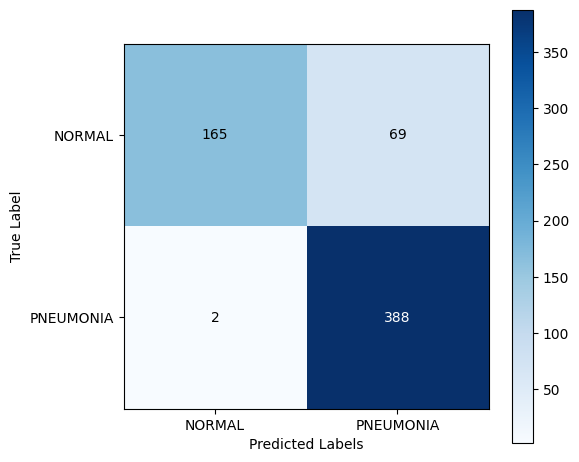

AUC: 0.9738
ROC curve saved: /content/eval_outputs/roc_curve.png


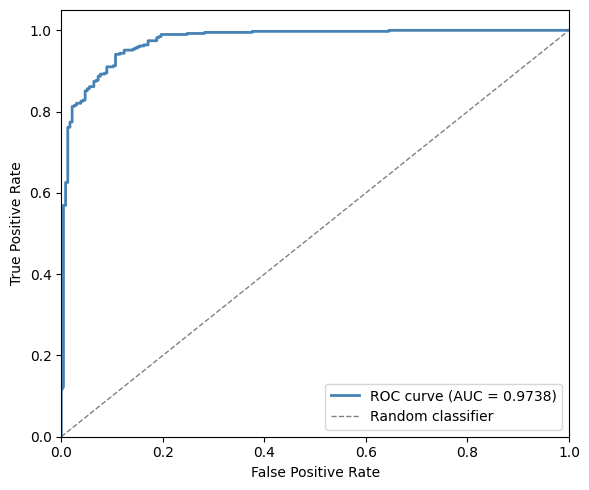


Accuracy: 0.8862 | AUC 0.9738

Final Test Accuracy : 0.8862
Final Test AUC      : 0.9738


In [39]:
# Eval
EVAL_DIR = Path("/content/eval_outputs")
EVAL_DIR.mkdir(parents=True, exist_ok=True)

metrics = run_full_evaluation(
    model=model,
    loader=test_loader,
    device=device,
    save_dir=EVAL_DIR
)

print(f"\nFinal Test Accuracy : {metrics['accuracy']:.4f}")
print(f"Final Test AUC      : {metrics['auc']:.4f}")


In [40]:
# Push to HF
from huggingface_hub import login, HfApi

login()

api = HfApi()
repo_id = "theinferenceloop/adversarial-ai-target"

api.create_repo(repo_id=repo_id, exist_ok=True)

api.upload_file(
    path_or_fileobj=str(MODEL_DIR / "best_checkpoint.pt"),
    path_in_repo="best_checkpoint.pt",
    repo_id=repo_id
)

print(f"Model pushed to HuggingFace: {repo_id}")

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...models/best_checkpoint.pt:   1%|1         |  555kB / 43.4MB            

Model pushed to HuggingFace: theinferenceloop/adversarial-ai-target


In [41]:
# Cell 11b: Create and push model card
model_card = """---
license: mit
tags:
- medical-imaging
- chest-xray
- pneumonia-detection
- efficientnet
- pytorch
- adversarial-ai
pipeline_tag: image-classification
---

# adversarial-ai-target

EfficientNet-B3 fine-tuned for binary chest X-ray classification.
Built as the primary attack target for the [adversarial-ai-attacks-mitigations](https://github.com/emsikes/adversarial-ai-attacks-mitigations) research series.

## Model Details

| Property | Value |
|---|---|
| Architecture | EfficientNet-B3 (ImageNet pretrained) |
| Task | Binary image classification |
| Classes | NORMAL (0), PNEUMONIA (1) |
| Input size | 300 × 300 RGB |
| Framework | PyTorch 2.0 |
| Dataset | [Kaggle chest-xray-pneumonia](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia) |

## Training

| Property | Value |
|---|---|
| Phase 1 (epochs 1-4) | Backbone frozen, head only, lr=1e-3 |
| Phase 2 (epochs 5-10) | Last 3 backbone blocks unfrozen, lr=1e-4 |
| Optimizer | AdamW |
| Scheduler | CosineAnnealingLR |
| Batch size | 64 (A100) |
| Class balancing | WeightedRandomSampler |

## Performance

| Metric | Value |
|---|---|
| Test Accuracy | 0.8862 |
| AUC | 0.9738 |
| PNEUMONIA Recall | 0.99 |
| NORMAL Precision | 0.99 |

## Intended Use

This model is intended strictly for adversarial AI security research and education.
It serves as the attack surface for chapters 4-9 and 12 of the hands-on lab series
covering poisoning attacks, evasion attacks, model extraction, membership inference,
and GAN-based attacks.

**Do not use this model for clinical decision making.**

## Research Series

Part of [The Inference Loop](https://theinferenceloop.substack.com) research series.
"""

# Write model card locally
with open("/content/README.md", "w") as f:
    f.write(model_card)

# Push to HuggingFace
api.upload_file(
    path_or_fileobj="/content/README.md",
    path_in_repo="README.md",
    repo_id=repo_id
)

print("Model card pushed to HuggingFace.")

Model card pushed to HuggingFace.


In [42]:
# Cell 12: Push eval outputs to Drive
import shutil

dest = REPO_PATH / "ch01_ml_foundations" / "eval_outputs"
if dest.exists():
    shutil.rmtree(dest)
shutil.copytree(EVAL_DIR, dest)

print(f"Eval outputs saved to repo: {dest}")
print("Done. Sync your Google Drive folder to pull results locally.")

Eval outputs saved to repo: /content/drive/MyDrive/adversarial-ai-attacks-mitigations/ch01_ml_foundations/eval_outputs
Done. Sync your Google Drive folder to pull results locally.


In [43]:
# Cell 13: Model card summary
print("\n=== Model Card Summary ===")
print(f"Model      : EfficientNet-B3")
print(f"Task       : Binary chest X-ray classification")
print(f"Classes    : NORMAL (0), PNEUMONIA (1)")
print(f"Dataset    : Kaggle chest-xray-pneumonia (5,863 images)")
print(f"Input size : 300x300 RGB")
print(f"Accuracy   : {metrics['accuracy']:.4f}")
print(f"AUC        : {metrics['auc']:.4f}")
print(f"HuggingFace: theinferenceloop/adversarial-ai-target")
print(f"Attack surface: ch04-ch09, ch12")


=== Model Card Summary ===
Model      : EfficientNet-B3
Task       : Binary chest X-ray classification
Classes    : NORMAL (0), PNEUMONIA (1)
Dataset    : Kaggle chest-xray-pneumonia (5,863 images)
Input size : 300x300 RGB
Accuracy   : 0.8862
AUC        : 0.9738
HuggingFace: theinferenceloop/adversarial-ai-target
Attack surface: ch04-ch09, ch12
